In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.subtyping_em_transformer import SubtypingEM

np.set_printoptions(precision=4)

In [2]:
# data params
n_biomarkers = 3
t_max = 25 # was 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.0
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 2 #3,4,5
rng = np.random.RandomState(75)

For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.

SUBTYPE 0:
f: [0.  0.  0.3]
a = 4.676436127196727, b = 6.421955999238555


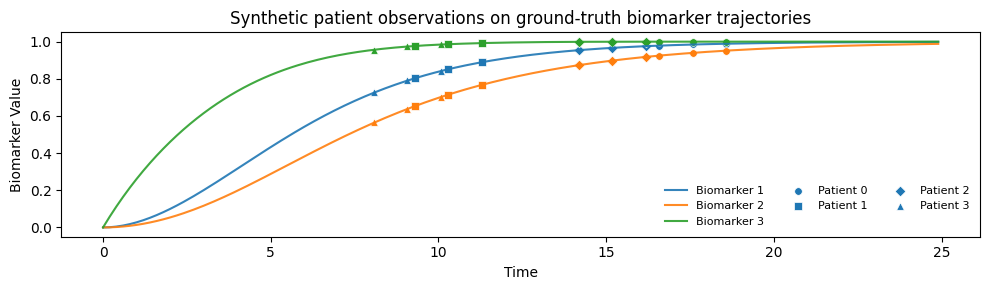

11.371801905439074
SUBTYPE 1:
f: [0.2 0.  0. ]
a = 1.1927249100009507, b = 6.8096301386771785


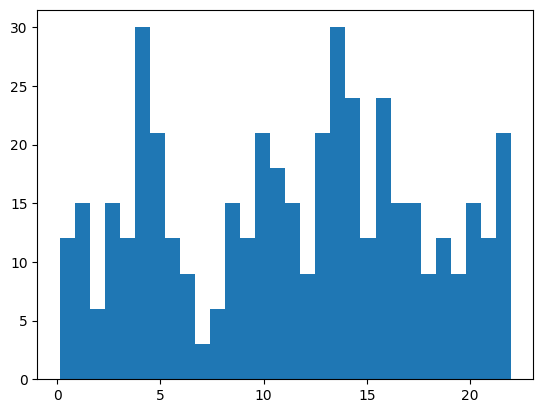

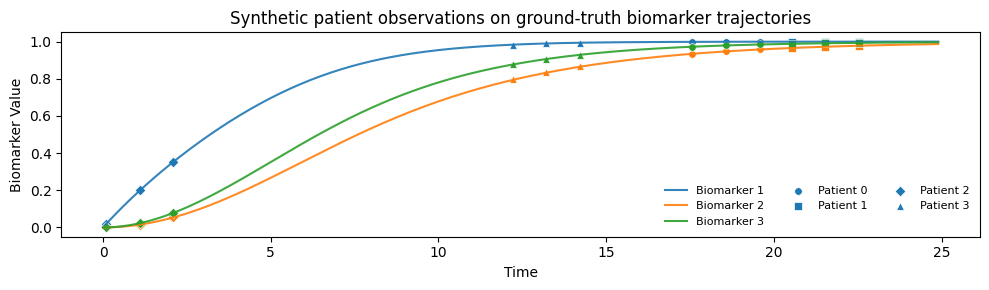

10.680411768908934


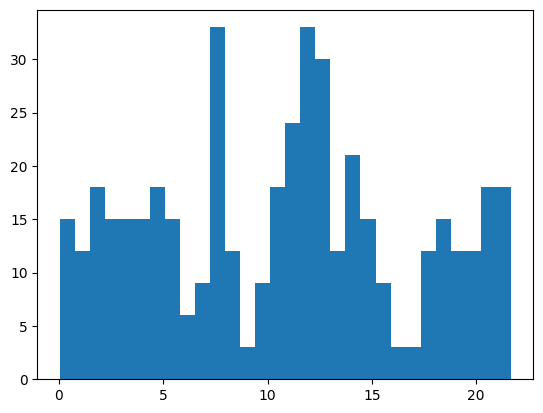

In [3]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.2, 0.2]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

f_list = [np.array([0.0, 0.0, 0.3]), np.array([0.2, 0.0, 0.0])]

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype + 2),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    #print(f"dt shape: {dt.shape}\nids shape: {ids.shape}\ncog shape: {cog.shape}\nbeta shape: {beta_true.shape}")
    #print(beta_true)

    plt.hist(beta_true, bins=30)
    print(np.mean(beta_true))
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    #  print(beta_true[::n_patient_obs][0:10])
    
X = np.asarray(X)
y = np.concatenate(y)

# print(len(X))
# print(len(y))#, y)
# print(y)

In [4]:
all_dt = np.concatenate([p["dt"] for p in X])
all_cog = np.concatenate([p["cog"] for p in X])
all_ids_array = np.concatenate([[p["id"]] * len(p["dt"]) for p in X])

initial_beta, pid_to_beta, result = fit_mixedlm_beta_from_clinical(
    ids=all_ids_array,
    dt=all_dt,
    cog=all_cog,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

unique_ids = np.unique([p["id"] for p in X])
beta_true_array = y
        
print(f"Initialized beta for {len(initial_beta)} patients")
print(f"Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"True beta range: [{np.min(beta_true_array):.2f}, {np.max(beta_true_array):.2f}]")


β_init summary: count    300.000000
mean      10.788830
std        8.559708
min        0.000000
25%        4.011096
50%        7.336175
75%       19.590477
max       25.000000
dtype: float64
Initialized beta for 300 patients
Beta range: [0.00, 25.00]
True beta range: [0.05, 21.97]


## fit() Call

The SubtypingEM algorithm performs:
1. Global s parameter estimation
2. Cluster assignment (hard assignment for now)
3. Cluster-level f and scalar_K estimation
4. Patient-level beta estimation

In [5]:
f_init = initialize_f_eigen(K=K)
if isinstance(f_init, list):
    f_init = f_init[0]

# Add initial_beta to patient data (from cell 4)
unique_ids = np.unique([p["id"] for p in X])
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
for p in X:
    p["initial_beta"] = initial_beta[id_to_beta_idx[p["id"]]]


In [22]:
subtyping_em = SubtypingEM(
    K=K,
    initial_f=f_init,
    n_subtypes=n_subtypes,
    jac_toggle=True,
    max_iter=1000,
    t_max=t_max,
    step=0.01,
    epsilon=1e-2,
    lambda_f=0.01,
    lambda_cog=0.001,
    lambda_scalar=0.01,
    verbose=1,
    rng=np.random.default_rng(75)
)

subtyping_em.fit(X)

  1%|          | 9/1000 [00:54<1:39:53,  6.05s/it]


SubtypingEM(K=array([[0.    , 0.6422, 1.    ],
       [0.6422, 0.    , 0.4611],
       [1.    , 0.4611, 0.    ]]),
            initial_f=array([[0.6021, 0.4866, 0.6256]]), jac_toggle=True,
            lambda_cog=0.001, lambda_scalar=0.01, max_iter=1000,
            rng=Generator(PCG64) at 0x7FA833C4C2E0, t_max=25)

In [ ]:
subtyping_em.compute_subtype_mapping(f_list, verbose=True)
subtype_mapping = subtyping_em.subtype_mapping # store for plotting later

print_parameter_comparison(
    fitted_f_list=subtyping_em.cluster_f,
    fitted_scalar_K_list=subtyping_em.cluster_scalar_K,
    fitted_s=subtyping_em.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),  # s is typically all ones in synthetic data
    subtype_mapping=subtyping_em.subtype_mapping,
    n_subtypes=n_subtypes,
)

# Confusion matrix for single fit
from sklearn.metrics import confusion_matrix
assignments_true = np.array([p["subtype_true"] for p in X])
# Map fitted assignments using subtype mapping
mapped_assignments = subtype_mapping[subtyping_em.final_assignments]
print("\n=== Confusion Matrix: Single Fit (with mapping) ===")
cm_single = confusion_matrix(assignments_true, mapped_assignments)
print(cm_single)


Subtype mapping (fitted -> true): [0 1]
  Fitted subtype 0 -> True subtype 0
  Fitted subtype 1 -> True subtype 1

Fitted Subtype 0 -> True Subtype 0:
  f_fitted:      [0.0597 0.0331 0.2332]
  f_true:        [0.  0.  0.3]
  scalar_K_fitted: 0.065965
  scalar_K_true:   0.200000

Fitted Subtype 1 -> True Subtype 1:
  f_fitted:      [0.2701 0.035  0.1091]
  f_true:        [0.2 0.  0. ]
  scalar_K_fitted: 0.150678
  scalar_K_true:   0.200000
  s_fitted:      [1.1195 1.1425 0.9636]
  s_true:        [1. 1. 1.]


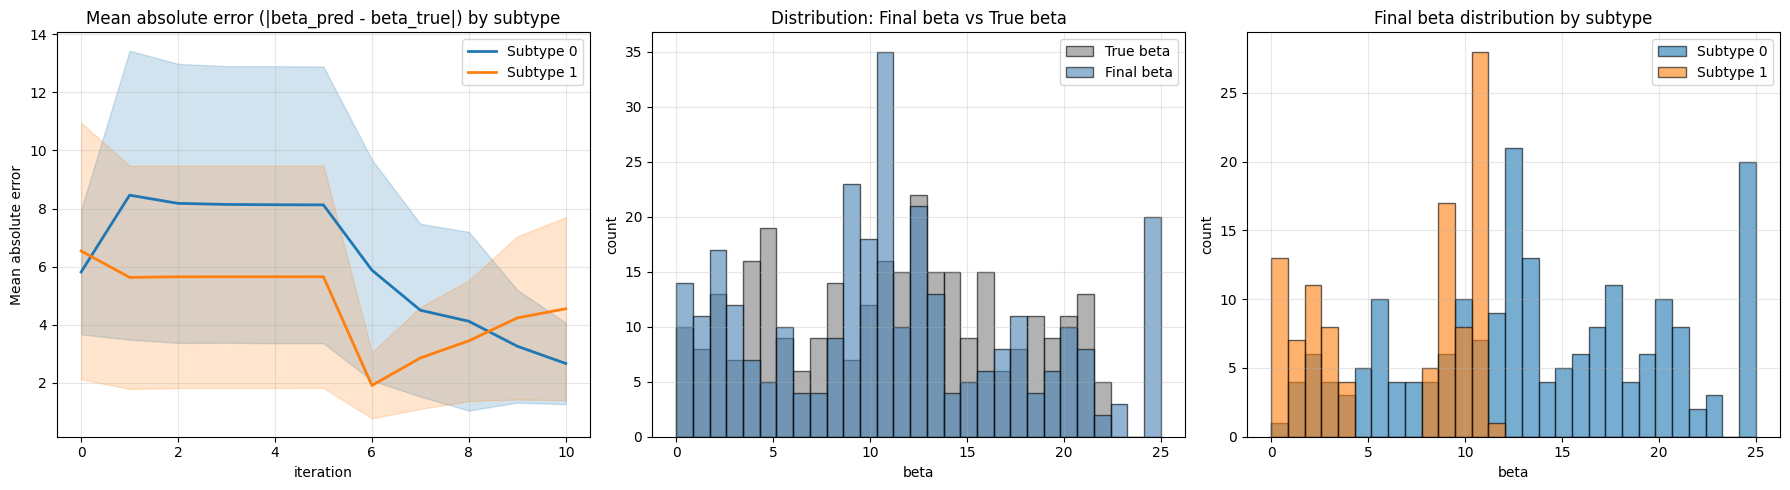

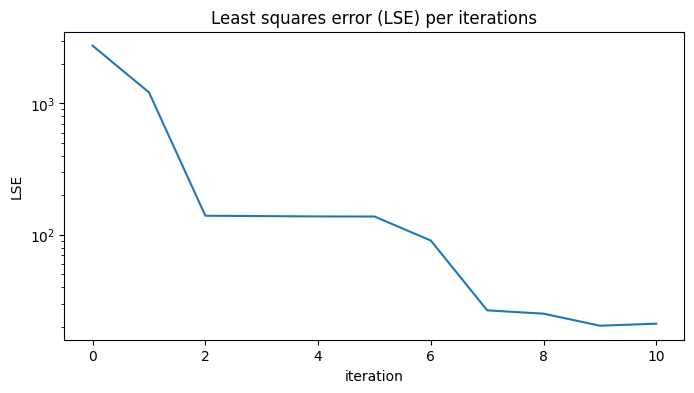

In [26]:
plot_beta_history_by_subtype(
    beta_history=subtyping_em.beta_history,
    assignments=subtyping_em.final_assignments,
    n_subtypes=n_subtypes,
    beta_true=beta_true_array,
    subtype_mapping=subtype_mapping if 'subtype_mapping' in locals() else None,
)

plot_lse(subtyping_em.lse_history)

## Multiple Initializations

Run multiple EM fits with different random initial cluster assignments in parallel to assess stability and convergence.


In [ ]:
from EMDPM.subtyping_em_transformer import run_multiple_initializations_parallel

# Prepare EM kwargs (same as single fit)
em_kwargs = {
    'K': K,
    'initial_f': f_init,
    'n_subtypes': n_subtypes,
    'jac_toggle': True,
    'max_iter': 1000,
    't_max': t_max,
    'step': 0.01,
    'epsilon': 1e-2,
    'lambda_f': 0.01,
    'lambda_cog': 0.001,
    'lambda_scalar': 0.01,
    'verbose': 0,
}

# Run multiple initializations in parallel
# Returns: results (list of all fitted models) and best_idx (index of best one)
n_initializations = 20
print(f"Running {n_initializations} initializations in parallel...")

results, best_idx = run_multiple_initializations_parallel(
    X=X,
    n_initializations=n_initializations,
    em_kwargs=em_kwargs,
    n_jobs=-1,  # Use all available cores mwahahahahaha
    prefer="processes",
    seed_offset=0,
    rng=np.random.default_rng(75)
)

print(f"\nCompleted {len(results)} initializations")
print(f"Best initialization (lowest final LSE): {best_idx}")
print(f"Best final LSE: {results[best_idx]['final_lse']:.6f}")

Running 20 initializations in parallel...



Completed 20 initializations
Best initialization (lowest final LSE): 18
Best final LSE: 15.508589


In [ ]:
# Compare best model with single fit
from sklearn.metrics import adjusted_rand_score, confusion_matrix, classification_report
best_model = results[best_idx]['model']

# Get ground truth assignments (needed for ARI calculation)
assignments_true = np.array([p["subtype_true"] for p in X])
best_model.compute_subtype_mapping(f_list, verbose=True)

# Print parameter comparison for best model
print_parameter_comparison(
    fitted_f_list=best_model.cluster_f,
    fitted_scalar_K_list=best_model.cluster_scalar_K,
    fitted_s=best_model.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),  # s is typically all ones in synthetic data
    subtype_mapping=best_model.subtype_mapping,
    n_subtypes=n_subtypes,
)

best_model_subtype_mapping = best_model.subtype_mapping

# Confusion matrix for best model
from sklearn.metrics import confusion_matrix
# Map fitted assignments using subtype mapping
mapped_assignments_best = best_model_subtype_mapping[best_model.final_assignments]
print("\n=== Confusion Matrix: Best Model (with mapping) ===")
cm_best = confusion_matrix(assignments_true, mapped_assignments_best)
print(cm_best)



Subtype mapping (fitted -> true): [1 0]
  Fitted subtype 0 -> True subtype 1
  Fitted subtype 1 -> True subtype 0

Fitted Subtype 0 -> True Subtype 1:
  f_fitted:      [0.4824 0.0678 0.    ]
  f_true:        [0.2 0.  0. ]
  scalar_K_fitted: 0.324136
  scalar_K_true:   0.200000

Fitted Subtype 1 -> True Subtype 0:
  f_fitted:      [0.     0.     0.2404]
  f_true:        [0.  0.  0.3]
  scalar_K_fitted: 0.206358
  scalar_K_true:   0.200000
  s_fitted:      [0.8861 0.8417 0.9949]
  s_true:        [1. 1. 1.]


=== Comparison: Single Fit vs Best Multiple Initialization ===

Single Fit:
  Final LSE: 21.101497
  Cluster sizes: [198 102]

Best Multiple Initialization:
  Final LSE: 15.508589
  Cluster sizes: [232  68]

=== Assignment Quality ===
Single fit ARI: 0.4608
Best multi ARI: 0.2036


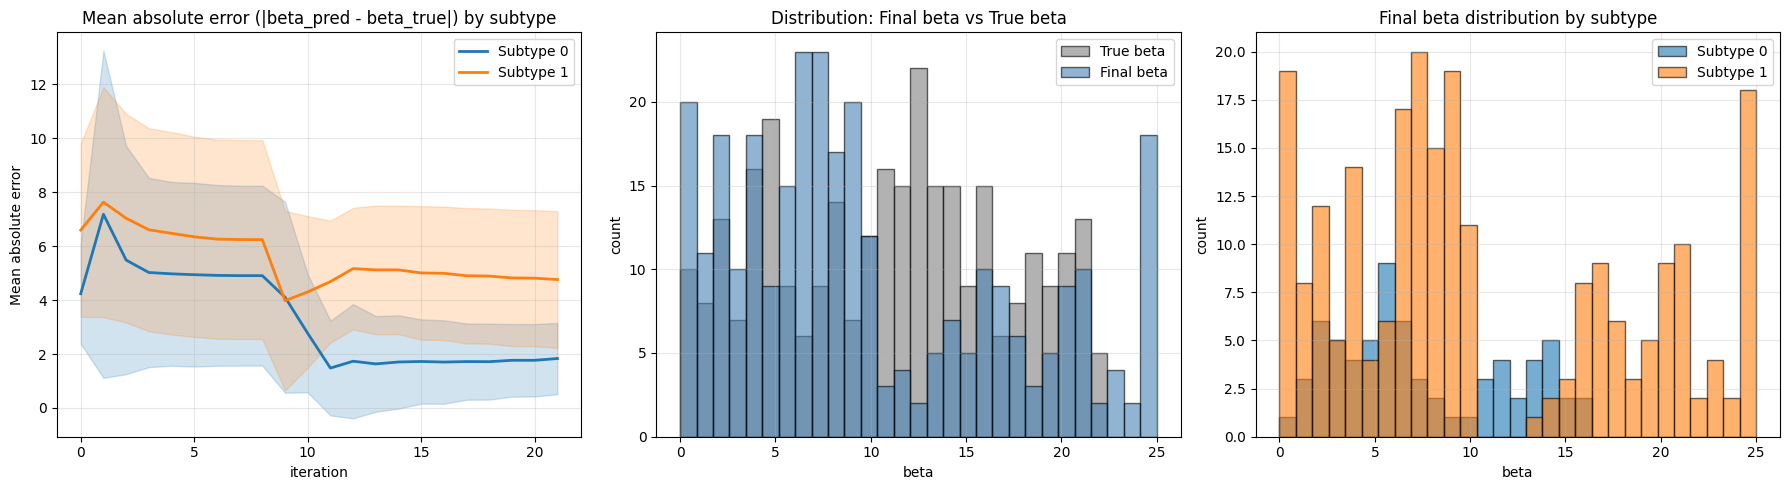

In [29]:

# Calculate ARI for single fit (needed for comparison)
assignments_single = subtyping_em.final_assignments
if hasattr(subtyping_em, 'final_assignments_matched') and subtyping_em.label_mapping_applied:
    assignments_single = subtyping_em.final_assignments_matched
ari_before = adjusted_rand_score(assignments_true, assignments_single)

print("=== Comparison: Single Fit vs Best Multiple Initialization ===\n")

print("Single Fit:")
print(f"  Final LSE: {subtyping_em.lse_history[-1]:.6f}")
print(f"  Cluster sizes: {np.bincount(subtyping_em.final_assignments)}")

print("\nBest Multiple Initialization:")
print(f"  Final LSE: {best_model.lse_history[-1]:.6f}")
print(f"  Cluster sizes: {np.bincount(best_model.final_assignments)}")

ari_best = adjusted_rand_score(assignments_true, assignments_best)
print(f"\n=== Assignment Quality ===")
print(f"Single fit ARI: {ari_before:.4f}")
print(f"Best multi ARI: {ari_best:.4f}")

# Plot beta history for best model
plot_beta_history_by_subtype(
    beta_history=best_model.beta_history,
    assignments=assignments_best,
    n_subtypes=n_subtypes,
    beta_true=beta_true_array,
    subtype_mapping=best_model_subtype_mapping,
)


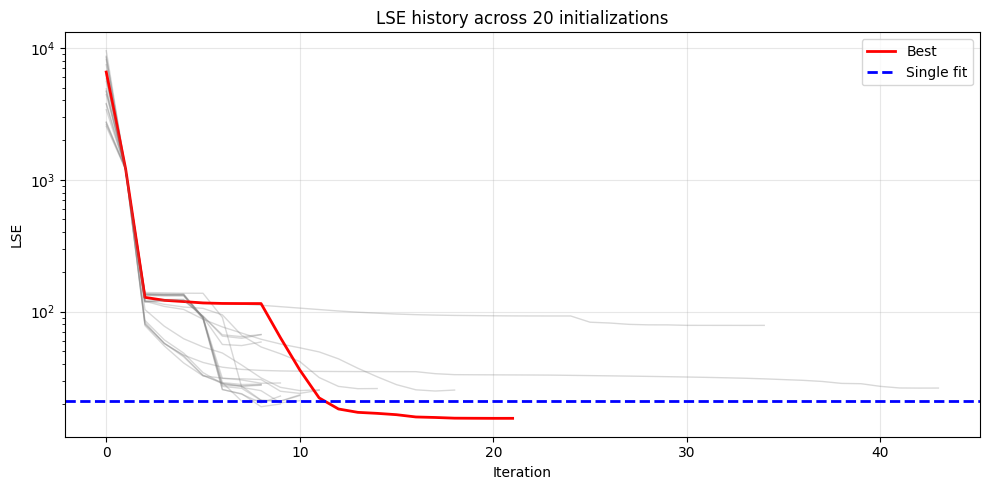

In [11]:
# Plot LSE history for all initializations
plt.figure(figsize=(10, 5))
for i, result in enumerate(results):
    lse_history = result['lse_history']
    color = 'red' if i == best_idx else 'gray'
    alpha = 1.0 if i == best_idx else 0.3
    linewidth = 2 if i == best_idx else 1
    label = 'Best' if i == best_idx else None
    plt.plot(lse_history, color=color, alpha=alpha, linewidth=linewidth, label=label)

plt.axhline(y=subtyping_em.lse_history[-1], color='blue', linestyle='--', linewidth=2, label='Single fit')
plt.xlabel('Iteration')
plt.ylabel('LSE')
plt.title(f'LSE history across {n_initializations} initializations')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


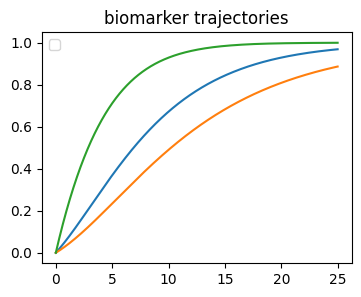

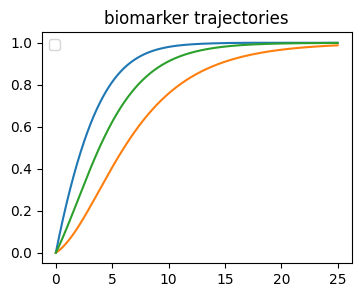

In [ ]:
# Plot cluster trajectories

for subtype in range(n_subtypes):
    f_cluster = subtyping_em.cluster_f[subtype]
    scalar_K_cluster = subtyping_em.cluster_scalar_K[subtype]
    cluster_trajectory = solve_system(
        x0=np.zeros(n_biomarkers),
        f=f_cluster,
        K=K,
        t_span=t_span,
        scalar_K=scalar_K_cluster
    )
    plot_biomarker_trajectories(
        biom_trajectories=cluster_trajectory,
        t_span=t_span,
        n_biomarkers=n_biomarkers,
    )

## Cluster Assignment Evaluation

evaluate how well the algorithm recovered the true subtypes.

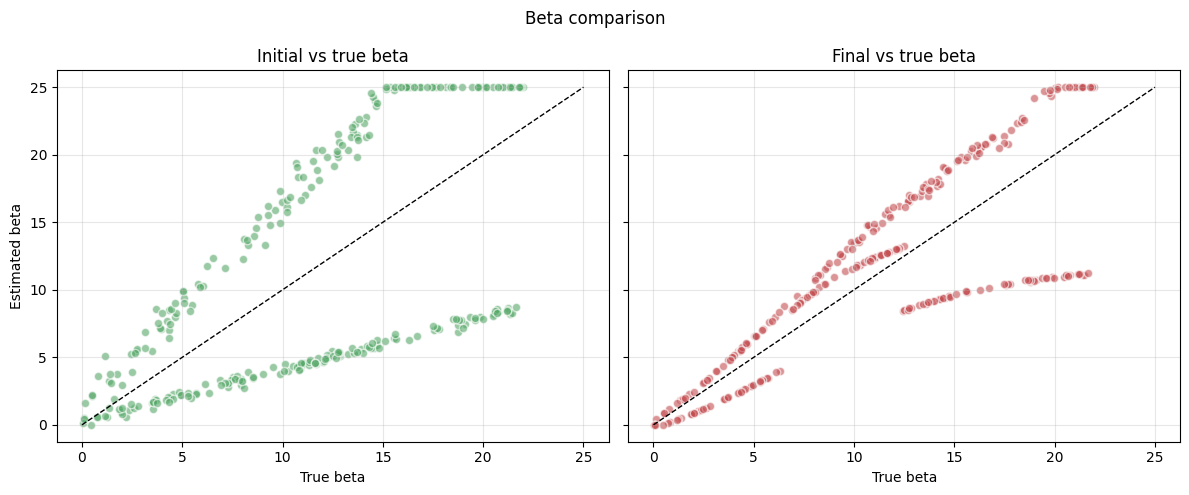

In [17]:
# Plot initial and final beta estimates against true beta
beta_init_array = np.array([p.get("initial_beta", np.nan) for p in X])
if np.any(np.isnan(beta_init_array)):
    # Fallback: use the initial_beta array directly
    beta_init_array = initial_beta

beta_final_array = subtyping_em.beta_history[:, -1]

plot_beta_comparison(beta_true_array, beta_init_array, beta_final_array)

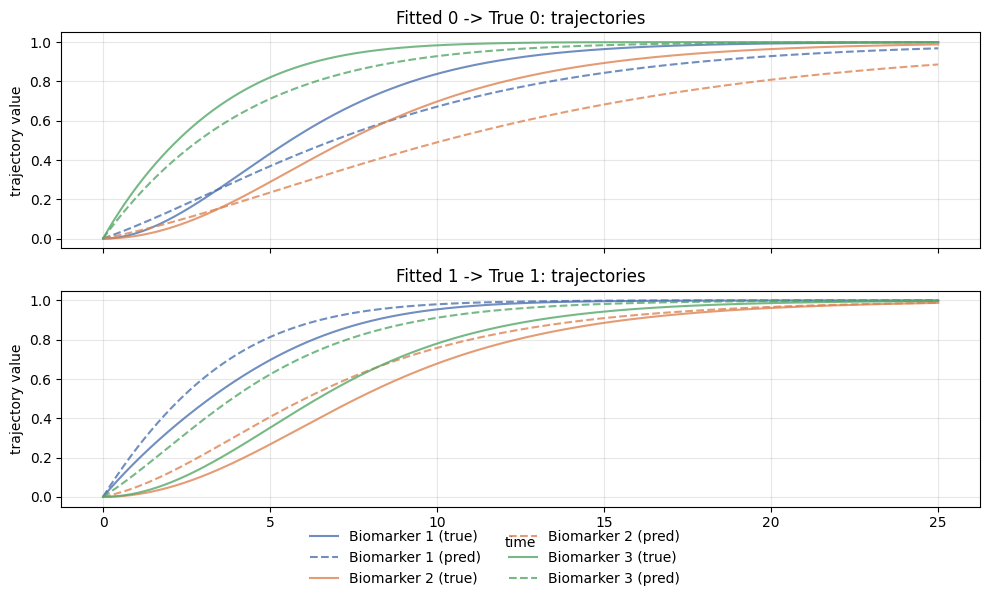

NameError: name 'plot_assignment_accuracy_over_iterations' is not defined

In [ ]:
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=subtyping_em.cluster_f,
    scalar_K_pred_list=subtyping_em.cluster_scalar_K,
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=subtype_mapping,
)

# Confusion matrix for single fit
from sklearn.metrics import confusion_matrix
assignments_true = np.array([p["subtype_true"] for p in X])
# Map fitted assignments to true subtypes using subtype_mapping
mapped_assignments = np.array([subtype_mapping[a] for a in subtyping_em.final_assignments])
cm_single = confusion_matrix(assignments_true, mapped_assignments)
print("\n=== Single Fit: Confusion Matrix (with subtype mapping) ===")
print(cm_single)

# Plot assignment accuracy over iterations for single fit
plot_assignment_accuracy_history(
    assignment_history=subtyping_em.assignment_history,
    true_assignments=assignments_true,
    subtype_mapping=subtype_mapping,
    title="Single Fit: Assignment Accuracy Over Iterations",
)



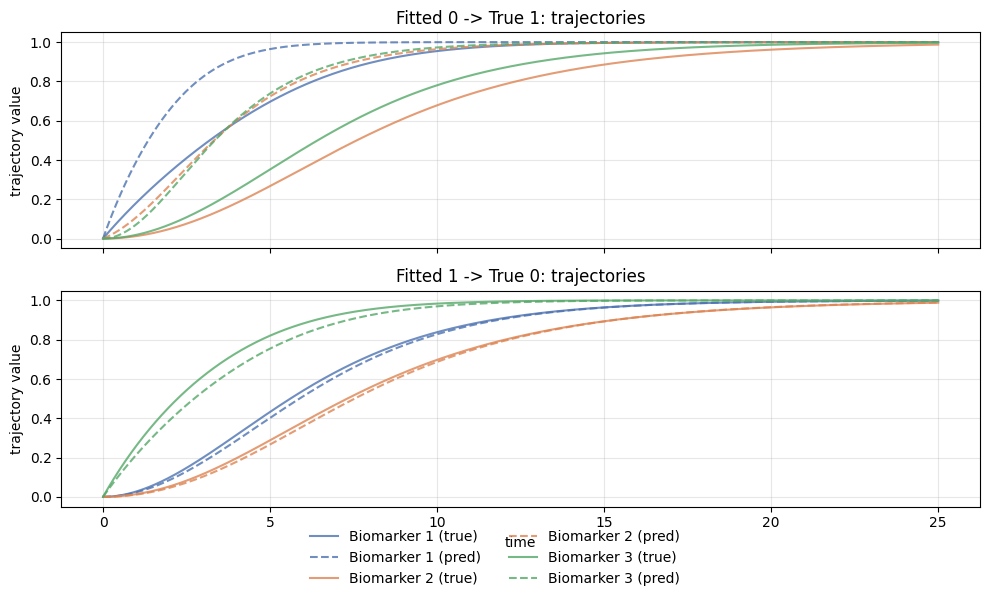

In [ ]:
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=best_model.cluster_f,
    scalar_K_pred_list=best_model.cluster_scalar_K,
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=best_model_subtype_mapping,
)

# Confusion matrix for best model
from sklearn.metrics import confusion_matrix
assignments_true = np.array([p["subtype_true"] for p in X])
# Map fitted assignments to true subtypes using subtype_mapping
mapped_assignments_best = np.array([best_model_subtype_mapping[a] for a in best_model.final_assignments])
cm_best = confusion_matrix(assignments_true, mapped_assignments_best)
print("\n=== Best Model: Confusion Matrix (with subtype mapping) ===")
print(cm_best)

# Plot assignment accuracy over iterations for best model
plot_assignment_accuracy_history(
    assignment_history=best_model.assignment_history,
    true_assignments=assignments_true,
    subtype_mapping=best_model_subtype_mapping,
    title="Best Model: Assignment Accuracy Over Iterations",
)

